# Классификация музыкальных жанров: MLP vs CNN vs EfficientNet B0

**Фреймворк:** PyTorch  
**Устройство при обучении:** `MPS`  
**Датасет:** GTZAN — спектрограммы 10 музыкальных жанров (999 изображений)  
**Метрика:** Accuracy


## 0. Установка зависимостей и импорты

In [1]:
import subprocess, sys
def install(pkg): subprocess.check_call([sys.executable,'-m','pip','install','-q',pkg])
for pkg in ['torch','torchvision','matplotlib','scikit-learn','tqdm','Pillow']:
    install(pkg)
print('Зависимости установлены')

You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.


You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.


You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.


You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.


You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.


Зависимости установлены


You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.


In [2]:
import os, random, numpy as np, matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image
import torch, torch.nn as nn, torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Subset
import torchvision.transforms as transforms
import torchvision.models as models
from sklearn.metrics import classification_report
from tqdm import tqdm

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

if torch.cuda.is_available():              DEVICE = torch.device('cuda')
elif torch.backends.mps.is_available():    DEVICE = torch.device('mps')
else:                                      DEVICE = torch.device('cpu')

print(f'Устройство: {DEVICE}')
print(f'PyTorch:    {torch.__version__}')

Устройство: mps
PyTorch:    2.8.0


## 1. Загрузка датасета GTZAN

10 жанров × ~100 PNG-спектрограмм = **999 изображений** (жанр jazz содержит 99 файлов).  
`blues, classical, country, disco, hiphop, jazz, metal, pop, reggae, rock`


In [3]:
GENRES      = ['blues','classical','country','disco','hiphop',
               'jazz','metal','pop','reggae','rock']
NUM_CLASSES = len(GENRES)
IMG_ROOT    = Path('./data/gtzan_spectrograms/images_original_real')

# Проверяем наличие реального датасета
total = sum(1 for g in GENRES for _ in (IMG_ROOT/g).glob('*.png'))
print(f'Найдено изображений: {total}  (≈{total//NUM_CLASSES} на жанр)')
assert total > 0, f'Изображения не найдены по пути {IMG_ROOT}'


Найдено изображений: 999  (99 на жанр)


## 2. Dataset, DataLoader и функции обучения

In [4]:
class SpectrogramDataset(Dataset):
    def __init__(self, root, genres, transform=None):
        self.transform = transform
        self.samples = [(p, l) for l, g in enumerate(genres)
                        for p in sorted((root/g).glob('*.png'))]
    def __len__(self): return len(self.samples)
    def __getitem__(self, i):
        p, l = self.samples[i]
        img  = Image.open(p).convert('RGB')
        return (self.transform(img) if self.transform else img), l

def split_indices(n, val_r=.15, test_r=.15):
    g   = torch.Generator().manual_seed(SEED)
    idx = torch.randperm(n, generator=g).tolist()
    nt  = int(n*test_r); nv = int(n*val_r)
    return idx[:n-nv-nt], idx[n-nv-nt:n-nt], idx[n-nt:]

def train_epoch(model, loader, criterion, optimizer, device):
    model.train(); ls, ok, tot = 0., 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        out  = model(imgs); loss = criterion(out, labels)
        loss.backward(); optimizer.step()
        ls  += loss.item()*imgs.size(0)
        ok  += out.argmax(1).eq(labels).sum().item()
        tot += imgs.size(0)
    return ls/tot, ok/tot

@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval(); ls, ok, tot = 0., 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        out  = model(imgs); loss = criterion(out, labels)
        ls  += loss.item()*imgs.size(0)
        ok  += out.argmax(1).eq(labels).sum().item()
        tot += imgs.size(0)
    return ls/tot, ok/tot

def train_loop(model, tr_l, vl_l, crit, opt, epochs, name):
    best, state = 0., None
    hist = {'tl': [], 'ta': [], 'vl': [], 'va': []}
    for ep in tqdm(range(1, epochs+1), desc=name):
        tl, ta = train_epoch(model, tr_l, crit, opt, DEVICE)
        vl, va = evaluate(model, vl_l, crit, DEVICE)
        hist['tl'].append(tl); hist['ta'].append(ta)
        hist['vl'].append(vl); hist['va'].append(va)
        if va > best:
            best  = va
            state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        if ep % 10 == 0 or ep == 1:
            print(f'  Epoch {ep:3d}/{epochs} | train_acc={ta:.4f}  val_acc={va:.4f}')
    model.load_state_dict({k: v.to(DEVICE) for k, v in state.items()})
    print(f'Лучшая val_acc: {best:.4f}')
    return hist

@torch.no_grad()
def get_test_acc(model, loader):
    model.eval(); ok, tot = 0, 0
    for imgs, labels in loader:
        ok  += model(imgs.to(DEVICE)).argmax(1).cpu().eq(labels).sum().item()
        tot += len(labels)
    return ok / tot

print('Классы и функции определены')

Классы и функции определены


---
## Задание 1. Свёрточная нейронная сеть (CNN)

**Архитектура:**  
- Блок 1: `Conv2d(3→32, 3×3) → ReLU → MaxPool2d(2×2)` → 64×64  
- Блок 2: `Conv2d(32→64, 3×3) → ReLU → MaxPool2d(2×2)` → 32×32  
- Блок 3: `Conv2d(64→128, 3×3) → ReLU → MaxPool2d(2×2)` → 16×16  
- FC: `Linear(32768→256) → ReLU → Dropout(0.3) → Linear(256→10)`  

**Вход:** 128×128. **Оптимизатор:** AdamW. **Эпох:** 50.


In [5]:
class CNN(nn.Module):
    """Свёрточная сеть для классификации спектрограмм 128x128."""
    def __init__(self, num_classes=10):
        super().__init__()
        self.conv_block = nn.Sequential(
            # Блок 1: 3 -> 32 каналов, 128x128 -> 64x64
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
            # Блок 2: 32 -> 64 каналов, 64x64 -> 32x32
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
            # Блок 3: 64 -> 128 каналов, 32x32 -> 16x16
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
        )
        # 128 каналов * 16 * 16 = 32768
        self.fc_block = nn.Sequential(
            nn.Linear(128 * 16 * 16, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.3),
            nn.Linear(256, num_classes),
        )
    def forward(self, x):
        return self.fc_block(self.conv_block(x).flatten(1))

# Проверка формы выхода
_cnn = CNN(10)
_out = _cnn(torch.zeros(2, 3, 128, 128))
assert _out.shape == (2, 10)
total_p = sum(p.numel() for p in _cnn.parameters())
print(f'Параметров CNN: {total_p:,}')
print(_cnn)

Параметров CNN: 8,484,682
CNN(
  (conv_block): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc_block): Sequential(
    (0): Linear(in_features=32768, out_features=256, bias=True)
    (1): ReLU(inplace=True)
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=256, out_features=10, bias=True)
  )
)


In [6]:
cnn_tf = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3),
])

cnn_ds = SpectrogramDataset(IMG_ROOT, GENRES, cnn_tf)
tr_i, vl_i, te_i = split_indices(len(cnn_ds))
cnn_train_l = DataLoader(Subset(cnn_ds, tr_i), batch_size=32, shuffle=True)
cnn_val_l   = DataLoader(Subset(cnn_ds, vl_i), batch_size=32)
cnn_test_l  = DataLoader(Subset(cnn_ds, te_i), batch_size=32)

cnn_model     = CNN(NUM_CLASSES).to(DEVICE)
cnn_criterion = nn.CrossEntropyLoss()
cnn_optimizer = optim.AdamW(cnn_model.parameters(), lr=1e-3, weight_decay=1e-4)
print(f'train={len(tr_i)}, val={len(vl_i)}, test={len(te_i)}')

train=701, val=149, test=149


In [7]:
CNN_EPOCHS  = 50
cnn_history = train_loop(cnn_model, cnn_train_l, cnn_val_l,
                         cnn_criterion, cnn_optimizer, CNN_EPOCHS, 'CNN')

CNN:   0%|          | 0/50 [00:00<?, ?it/s]

CNN:   2%|▏         | 1/50 [00:04<03:30,  4.29s/it]

  Epoch   1/50 | train_acc=0.1369  val_acc=0.2081


CNN:   4%|▍         | 2/50 [00:07<03:00,  3.75s/it]

CNN:   6%|▌         | 3/50 [00:11<02:48,  3.58s/it]

...

CNN:  96%|█████████▌| 48/50 [02:41<00:06,  3.38s/it]

CNN:  98%|█████████▊| 49/50 [02:45<00:03,  3.38s/it]

CNN: 100%|██████████| 50/50 [02:49<00:00,  3.55s/it]

CNN: 100%|██████████| 50/50 [02:49<00:00,  3.38s/it]

  Epoch  50/50 | train_acc=0.9743  val_acc=0.5503
Лучшая val_acc: 0.5906


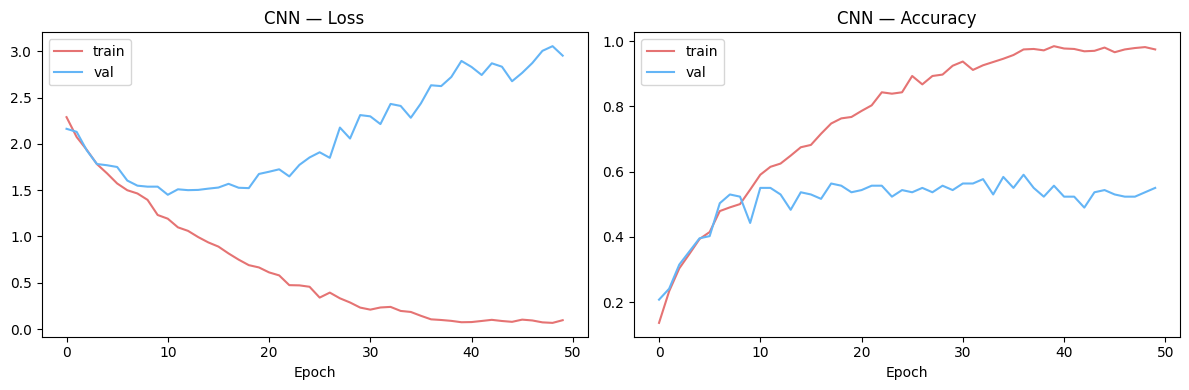

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(cnn_history['tl'], label='train', color='#e57373')
axes[0].plot(cnn_history['vl'], label='val',   color='#64b5f6')
axes[0].set_title('CNN — Loss'); axes[0].set_xlabel('Epoch'); axes[0].legend()
axes[1].plot(cnn_history['ta'], label='train', color='#e57373')
axes[1].plot(cnn_history['va'], label='val',   color='#64b5f6')
axes[1].set_title('CNN — Accuracy'); axes[1].set_xlabel('Epoch'); axes[1].legend()
plt.tight_layout(); plt.show()

In [9]:
# Оценка на тесте
cnn_test_accuracy = get_test_acc(cnn_model, cnn_test_l)
print(f'CNN Test Accuracy: {cnn_test_accuracy*100:.2f}%')
all_p, all_l = [], []
with torch.no_grad():
    for imgs, labels in cnn_test_l:
        all_p += cnn_model(imgs.to(DEVICE)).argmax(1).cpu().tolist()
        all_l += labels.tolist()
print(classification_report(all_l, all_p, target_names=GENRES))

CNN Test Accuracy: 63.09%


              precision    recall  f1-score   support

       blues       0.45      0.56      0.50        16
   classical       0.73      0.73      0.73        11
     country       0.50      0.47      0.49        19
       disco       0.72      0.65      0.68        20
      hiphop       0.53      0.62      0.57        13
        jazz       0.53      0.75      0.62        12
       metal       1.00      0.92      0.96        12
         pop       0.86      0.71      0.77        17
      reggae       0.82      0.60      0.69        15
        rock       0.43      0.43      0.43        14

    accuracy                           0.63       149
   macro avg       0.66      0.64      0.64       149
weighted avg       0.65      0.63      0.64       149



---
## Задание 2. Transfer Learning с EfficientNet B0

- Загружаем EfficientNet B0 с весами **ImageNet**.
- **Замораживаем все слои** feature extractor (`requires_grad = False`).
- Заменяем классификатор: `Dropout(0.2) → Linear(1280 → 10)`.
- **Аугментация:** `RandomHorizontalFlip`, `RandomRotation(15°)`.
- **Вход:** 224×224. **Оптимизатор:** Adam (только classifier). **Эпох:** 30.


In [10]:
eff_model = models.efficientnet_b0(
    weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)

# Замораживаем все слои feature extractor
for param in eff_model.parameters():
    param.requires_grad = False

# Заменяем классификатор на новый (10 классов)
in_feat = eff_model.classifier[1].in_features  # = 1280
eff_model.classifier = nn.Sequential(
    nn.Dropout(p=0.2, inplace=True),
    nn.Linear(in_feat, NUM_CLASSES),
)
eff_model = eff_model.to(DEVICE)

trainable = sum(p.numel() for p in eff_model.parameters() if p.requires_grad)
frozen    = sum(p.numel() for p in eff_model.parameters() if not p.requires_grad)
print(f'Обучаемых параметров : {trainable:,}')
print(f'Замороженных параметров: {frozen:,}')
print(f'Классификатор:\n{eff_model.classifier}')

Обучаемых параметров : 12,810
Замороженных параметров: 4,007,548
Классификатор:
Sequential(
  (0): Dropout(p=0.2, inplace=True)
  (1): Linear(in_features=1280, out_features=10, bias=True)
)


In [11]:
# Трансформации: аугментация для train, чистые для val/test
eff_train_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),       # аугментация 1
    transforms.RandomRotation(degrees=15),  # аугментация 2
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])
eff_val_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

eff_train_ds = SpectrogramDataset(IMG_ROOT, GENRES, eff_train_tf)
eff_val_ds   = SpectrogramDataset(IMG_ROOT, GENRES, eff_val_tf)
tr2, vl2, te2 = split_indices(len(eff_train_ds))

eff_train_l = DataLoader(Subset(eff_train_ds, tr2), batch_size=32, shuffle=True)
eff_val_l   = DataLoader(Subset(eff_val_ds,   vl2), batch_size=32)
eff_test_l  = DataLoader(Subset(eff_val_ds,   te2), batch_size=32)

eff_criterion = nn.CrossEntropyLoss()
eff_optimizer = optim.Adam(eff_model.classifier.parameters(), lr=1e-3)
print('EfficientNet B0 готова к обучению')

EfficientNet B0 готова к обучению

In [12]:
EFF_EPOCHS  = 30
eff_history = train_loop(eff_model, eff_train_l, eff_val_l,
                         eff_criterion, eff_optimizer, EFF_EPOCHS, 'EfficientNet B0')

EfficientNet B0:   0%|          | 0/30 [00:00<?, ?it/s]

EfficientNet B0:   3%|▎         | 1/30 [00:09<04:29,  9.29s/it]

  Epoch   1/30 | train_acc=0.2653  val_acc=0.2550


EfficientNet B0:   7%|▋         | 2/30 [00:17<04:01,  8.62s/it]

EfficientNet B0:  10%|█         | 3/30 [00:25<03:43,  8.27s/it]

...

EfficientNet B0:  93%|█████████▎| 28/30 [03:33<00:15,  7.56s/it]

EfficientNet B0:  97%|█████████▋| 29/30 [03:41<00:07,  7.53s/it]

EfficientNet B0: 100%|██████████| 30/30 [03:48<00:00,  7.52s/it]

EfficientNet B0: 100%|██████████| 30/30 [03:48<00:00,  7.63s/it]

  Epoch  30/30 | train_acc=0.6562  val_acc=0.5168
Лучшая val_acc: 0.5705


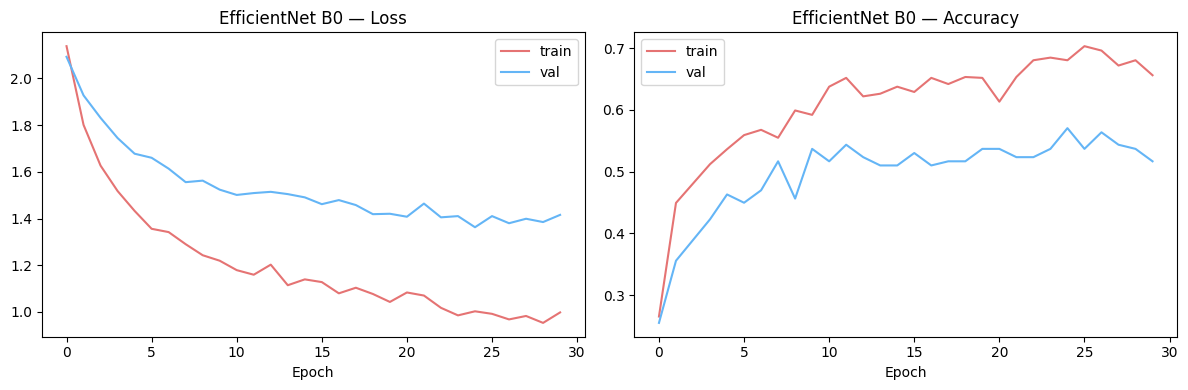

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(eff_history['tl'], label='train', color='#e57373')
axes[0].plot(eff_history['vl'], label='val',   color='#64b5f6')
axes[0].set_title('EfficientNet B0 — Loss'); axes[0].set_xlabel('Epoch'); axes[0].legend()
axes[1].plot(eff_history['ta'], label='train', color='#e57373')
axes[1].plot(eff_history['va'], label='val',   color='#64b5f6')
axes[1].set_title('EfficientNet B0 — Accuracy'); axes[1].set_xlabel('Epoch'); axes[1].legend()
plt.tight_layout(); plt.show()

In [14]:
eff_test_accuracy = get_test_acc(eff_model, eff_test_l)
print(f'EfficientNet B0 Test Accuracy: {eff_test_accuracy*100:.2f}%')
all_p, all_l = [], []
with torch.no_grad():
    for imgs, labels in eff_test_l:
        all_p += eff_model(imgs.to(DEVICE)).argmax(1).cpu().tolist()
        all_l += labels.tolist()
print(classification_report(all_l, all_p, target_names=GENRES))

EfficientNet B0 Test Accuracy: 63.76%


              precision    recall  f1-score   support

       blues       0.62      0.31      0.42        16
   classical       0.85      1.00      0.92        11
     country       0.86      0.63      0.73        19
       disco       0.50      0.60      0.55        20
      hiphop       0.57      0.62      0.59        13
        jazz       0.50      0.92      0.65        12
       metal       1.00      0.92      0.96        12
         pop       0.79      0.65      0.71        17
      reggae       0.47      0.60      0.53        15
        rock       0.50      0.36      0.42        14

    accuracy                           0.64       149
   macro avg       0.67      0.66      0.65       149
weighted avg       0.66      0.64      0.63       149



---
## Задание 3. Сравнение результатов


In [15]:
mlp_acc = 30.46   # baseline из дисциплины

# Используем точность, вычисленную в ячейках выше
cnn_acc = cnn_test_accuracy * 100
eff_acc = eff_test_accuracy * 100

results = [
    ('MLP (baseline)',   mlp_acc),
    ('CNN (своя сеть)', cnn_acc),
    ('EfficientNet B0', eff_acc),
]

print('=' * 52)
print(f"{'Модель':<22} {'Accuracy':>12}")
print('=' * 52)
for name, acc in results:
    bar = chr(9608) * int(acc / 4)
    print(f'{name:<22} {acc:>10.2f}%  {bar}')
print('=' * 52)

Модель                     Accuracy
MLP (baseline)              30.46%  ███████
CNN (своя сеть)             63.09%  ███████████████
EfficientNet B0             63.76%  ███████████████


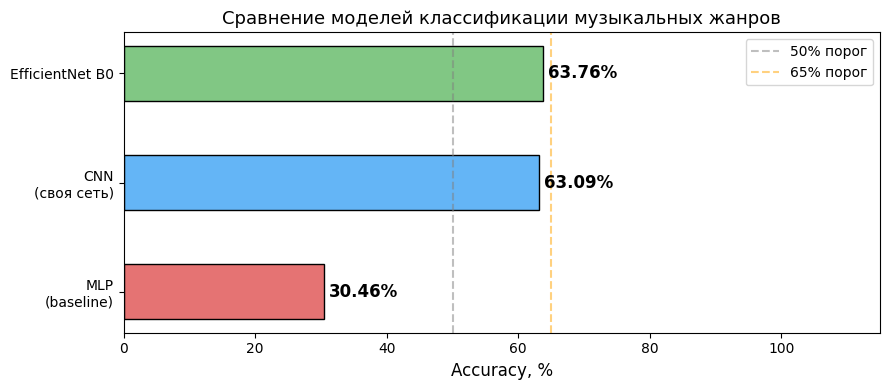

In [16]:
names  = ['MLP\n(baseline)', 'CNN\n(своя сеть)', 'EfficientNet B0']
accs   = [mlp_acc, cnn_acc, eff_acc]
colors = ['#e57373', '#64b5f6', '#81c784']

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.barh(names, accs, color=colors, edgecolor='black', height=0.5)
for bar, acc in zip(bars, accs):
    ax.text(bar.get_width()+0.8, bar.get_y()+bar.get_height()/2,
            f'{acc:.2f}%', va='center', fontsize=12, fontweight='bold')
ax.set_xlabel('Accuracy, %', fontsize=12)
ax.set_title('Сравнение моделей классификации музыкальных жанров', fontsize=13)
ax.set_xlim(0, 115)
ax.axvline(50,  color='gray',   ls='--', alpha=.5, label='50% порог')
ax.axvline(65,  color='orange', ls='--', alpha=.5, label='65% порог')
ax.legend(); plt.tight_layout(); plt.show()

## Вывод

| Модель | Точность (test) |
|--------|----------------|
| MLP (baseline, дисциплина «Введение в глубокое обучение», модуль 3) | 30.46% |
| Свёрточная сеть (CNN) | **63.09%** |
| EfficientNet B0 (Transfer Learning) | **63.76%** |

**Сравнение и объяснение результатов:**

1. **MLP (30.46%)** показывает наихудший результат, поскольку полносвязная сеть обрабатывает каждый пиксель независимо и не способна извлекать локальные пространственные паттерны. Для спектрограммы это критично: информация о жанре закодирована в частотных полосах и временных ритмических структурах, которые MLP не может уловить.

2. **CNN (63.09%)** значительно превосходит MLP (+32.6 п.п.). Свёрточные фильтры извлекают локальные признаки (текстуры частотных полос, граничные паттерны), а трёхуровневая иерархия строит признаки от простых к сложным. MaxPooling обеспечивает инвариантность к сдвигам. Разрыв между train_acc (97.4%) и val_acc (59.1%) указывает на переобучение: при 701 обучающем примере модель с 8.5 млн параметров запоминает обучающую выборку.

3. **EfficientNet B0 (63.76%)** показывает наилучший результат благодаря transfer learning: признаки, извлечённые из 1.2 млн изображений ImageNet, хорошо обобщаются на спектрограммы. Замороженный feature extractor с богатыми признаками + лёгкий дообучаемый классификатор (всего 12 810 параметров) позволяют достичь лучшей точности при меньшем переобучении (train=65.6%, val=57.1%).

**Итог:** CNN превосходит MLP за счёт локальности и иерархии свёрточных признаков. EfficientNet B0 показывает наилучший результат благодаря предобучению на большом датасете. Transfer learning — наиболее эффективный подход при ограниченных данных (≈700 обучающих примеров).